In [1]:
from numpy import expand_dims, zeros, ones, asarray
from numpy.random import randn, randint
import tensorflow as tf
from keras.optimizers import Adam
from keras.models import Model, Sequential
import tensorflow.keras.layers as tfl
from keras.layers import Input, Dense, Reshape, Flatten, Conv2D, Conv2DTranspose
from keras.layers import LeakyReLU, Dropout, Lambda, Activation
from matplotlib import pyplot as plt
from keras import backend as K
import numpy as np
from tqdm import tqdm
import os
import cv2 as cv
from keras.applications.vgg16 import preprocess_input
from sklearn.utils import shuffle


In [2]:
def define_generator(latent_dim):
	
	in_lat = Input(shape=(latent_dim,))
	n_nodes = 16*16*256
	X = Dense(n_nodes)(in_lat)
	X = LeakyReLU(alpha=.2)(X)
	X = Reshape((16, 16, 256))(X)
	
	X = Conv2DTranspose(64, (3,3), strides=(2,2), padding='same')(X)    #(32,32,64)
	X = LeakyReLU(alpha=.2)(X)
	
	X = Conv2DTranspose(32, (3,3), strides=(1,1), padding='same')(X)   #(32,32,32)
	X = LeakyReLU(alpha=.2)(X)
	out_layer = Conv2DTranspose(3, (3,3), strides=(2,2), activation='tanh', 
                             padding='same')(X) #(64,64,3)
	model = Model(in_lat, out_layer)
	return model


In [3]:
def define_discriminator(in_shape=(64,64,3), n_classes=2):
    
    in_image = Input(shape=in_shape)
    X = tfl.ZeroPadding2D(padding=(3,3)) (in_image)
    X = tfl.Conv2D(filters = 32, strides = 1, kernel_size=(7,7))(X)
    X = tfl.BatchNormalization(axis=-1) (X)
    X = tfl.ReLU()(X)
    X = tfl.Dropout(0.4) (X)
    X = tfl.Conv2D(filters = 64, strides = 1, kernel_size=(5,5)) (X)
    X = tfl.BatchNormalization(axis=-1) (X)
    X = tfl.ReLU()(X)
    X = tfl.Dropout(0.4) (X)
    X = tfl.MaxPool2D() (X)
    X = tfl.Flatten() (X)
    X = Dense(n_classes)(X)
    
    model = Model(inputs=in_image, outputs=X)
    
    return model

    return model

In [4]:
def define_sup_discriminator(disc):
    model=Sequential()
    model.add(disc)
    model.add(Activation('softmax'))
    model.compile(optimizer=Adam(learning_rate=0.0002, beta_1=0.5), 
                  loss="sparse_categorical_crossentropy",metrics=['accuracy'])
    return model


In [5]:
def custom_activation(x):
    Z_x = K.sum(K.exp(x), axis=-1, keepdims=True)
    D_x = Z_x /(Z_x+1)
    
    return D_x

In [6]:
def define_unsup_discriminator(disc):
    model=Sequential()
    model.add(disc)
    model.add(Lambda(custom_activation))
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5))
    return model

In [7]:
def define_gan(gen_model, disc_unsup):
	
	disc_unsup.trainable = False # make unsup. discriminator not trainable
	gan_output = disc_unsup(gen_model.output) #Gen. output is the input to disc. 
	model = Model(gen_model.input, gan_output)
	model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5))
	return model

In [8]:
def loadData(dir_path):
    X = []
    y = []
    labels = dict()
    i = 0
    for path in tqdm(sorted(os.listdir(dir_path))): #traverse through directories under Train/Val/Test
        if not path.startswith('.'):
            labels[i] = [0 if path == 'NO' else 1]
            for file in os.listdir(dir_path+'\\'+path):
                if not file.startswith('.'):
                    img = cv.imread(dir_path+'\\'+path+'\\'+file)
                    X.append(img)
                    y.append(i)
            i=i+1
    X = np.array(X,dtype='object')
    y = np.array(y)
    print(f'{len(X)} images loaded from {dir_path} directory.')
    return X,y,labels

In [9]:
X_train, y_train, labels = loadData(r'..\TRAIN')
X_val, y_val, _ = loadData(r'..\VAL')
X_test, y_test, _ = loadData(r'..\TEST')
def preprocess_imgs(set, img_size):
    set_new = []
    for img in set:
        img = cv.resize(img, dsize=img_size, interpolation=cv.INTER_CUBIC)
        set_new.append(preprocess_input(img))
    return np.array(set_new)
IMG_SIZE = (64,64)
X_train_fin = preprocess_imgs(set=X_train,img_size=IMG_SIZE)
X_val_fin = preprocess_imgs(set=X_val,img_size=IMG_SIZE)
X_test_fin = preprocess_imgs(set=X_test,img_size=IMG_SIZE)

100%|██████████| 2/2 [00:00<00:00, 14.83it/s]


559 images loaded from ..\TRAIN directory.


100%|██████████| 2/2 [00:00<00:00, 125.89it/s]


64 images loaded from ..\VAL directory.


100%|██████████| 2/2 [00:00<00:00, 139.14it/s]


65 images loaded from ..\TEST directory.


In [10]:
def load_real_samples():
    X = np.concatenate((X_train_fin, X_val_fin), axis=0)
    trainy = np.concatenate((y_train, y_val), axis=0)
    X = X.astype('float32')
    X = (X - 127.5) / 127.5  # scale from [0,255] to [-1,1] as we will be using tanh activation. 
    print(X.shape, trainy.shape)
    X_tf, y_tf = shuffle(X,trainy,random_state=42)
    return [X_tf, y_tf]

In [11]:
def select_supervised_samples(dataset, n_samples=20, n_classes=2):
	X, y = dataset
	X_list, y_list = list(), list()
	n_per_class = int(n_samples / n_classes) #Number of amples per class. 
	for i in range(n_classes):
		X_with_class = X[y == i] # get all images for this class
		ix = randint(0, len(X_with_class), n_per_class) # choose random images for each class
		[X_list.append(X_with_class[j]) for j in ix] # add to list
		[y_list.append(i) for j in ix]
	return asarray(X_list), asarray(y_list) #Returns a list of 2 numpy arrays corresponding to X and Y

In [12]:
def generate_real_samples(dataset, n_samples):
    
	images, labels = dataset
	ix = randint(0, images.shape[0], n_samples)
	X, labels = images[ix], labels[ix] #Select random images and corresponding labels
	y = ones((n_samples, 1)) #Label all images as 1 as these are real images. (for the discriminator training) 
	return [X, labels], y           # y = 1 => Real, 0 => Fake

In [13]:
def generate_latent_points(latent_dim, n_samples):
	z_input = randn(latent_dim * n_samples)
	z_input = z_input.reshape(n_samples, latent_dim) # reshape for input to the network
	return z_input

In [14]:
def generate_fake_samples(generator, latent_dim, n_samples):
	
	z_input = generate_latent_points(latent_dim, n_samples)
	fake_images = generator.predict(z_input)
	# create class labels
	y = zeros((n_samples, 1)) #Label all images as 0 as these are fake images. (for the discriminator training) 
	return fake_images, y

In [15]:
def summarize_performance(step, gen_model, disc_sup, latent_dim, dataset, n_samples=20):
	
	X, _ = generate_fake_samples(gen_model, latent_dim, n_samples)
	
	X = (X + 1) / 2.0 # scale to [0,1] for plotting
	
	for i in range(n_samples):
		plt.subplot(10, 10, 1 + i)
		plt.axis('off')
		plt.imshow(X[i, :, :, :], cmap='gray_r')
	
	filename1 = r'..\SSL_Graphs\generated_plot_%04d.png' % (step+1)
	plt.savefig(filename1)
	plt.close()
    
	
	X, y = dataset
	_, acc = disc_sup.evaluate(X, y, verbose=0)
	print('Discriminator Accuracy: %.3f%%' % (acc * 100))
	# save the generator model
	filename2 = r'..\SSL_Graphs\gen_model_%04d.h5' % (step+1)
	gen_model.save(filename2)
	# save the Discriminator (classifier) model
	filename3 = r'..\SSL_Graphs\disc_sup_%04d.h5' % (step+1)
	disc_sup.save(filename3)
	print('>Saved: %s, %s, and %s' % (filename1, filename2, filename3))

In [16]:
def train(gen_model, disc_unsup, disc_sup, gan_model, dataset, latent_dim, n_epochs=20, n_batch=20):
	
    # select supervised dataset for training.
    
	X_sup, y_sup = select_supervised_samples(dataset)
	#print(X_sup.shape, y_sup.shape)
	
	bat_per_epo = int(dataset[0].shape[0] / n_batch)
	# iterations
	n_steps = bat_per_epo * n_epochs
	
	half_batch = int(n_batch / 2)
	print('n_epochs=%d, n_batch=%d, 1/2=%d, b/e=%d, steps=%d' % (n_epochs, 
                                                              n_batch, half_batch, 
                                                              bat_per_epo, n_steps))
	
    #  enumerate epochs
	for i in range(n_steps):
		# update supervised discriminator (disc_sup) on real samples.
        #will be the class labels. 0 => Healthy, 1 => PD
		[Xsup_real, ysup_real], _ = generate_real_samples([X_sup, y_sup], half_batch)
		sup_loss, sup_acc = disc_sup.train_on_batch(Xsup_real, ysup_real)
        
		# update unsupervised discriminator (disc_unsup) - just like in our regular GAN.
        #The y_real below indicates 1s telling the discriminator that these images are real. 
        #We will discard this discriminator at the end. 
		[X_real, _], y_real = generate_real_samples(dataset, half_batch) 
		d_loss_real = disc_unsup.train_on_batch(X_real, y_real)
        #Now train on fake. 
		X_fake, y_fake = generate_fake_samples(gen_model, latent_dim, half_batch)
		d_loss_fake = disc_unsup.train_on_batch(X_fake, y_fake)
        
		# update generator (gen)
        #We can discard this model at the end as our primary goal is to train a multiclass classifier (sup. disc.)
		X_gan, y_gan = generate_latent_points(latent_dim, n_batch), ones((n_batch, 1))
		gan_loss = gan_model.train_on_batch(X_gan, y_gan)
        
		# summarize loss on this batch
		print('>%d, c[%.3f,%.0f], d[%.3f,%.3f], g[%.3f]' % (i+1, sup_loss, sup_acc*100, d_loss_real, d_loss_fake, gan_loss))
		# evaluate the model performance periodically
		if (i+1) % (bat_per_epo * 1) == 0:
			summarize_performance(i, gen_model, disc_sup, latent_dim, dataset)

In [17]:
latent_dim = 100

disc=define_discriminator() #Bare discriminator model... 
disc_sup=define_sup_discriminator(disc) #Supervised discriminator model
disc_unsup=define_unsup_discriminator(disc) #Unsupervised discriminator model. 

gen_model = define_generator(latent_dim) #Generator
gan_model = define_gan(gen_model, disc_unsup) #GAN
dataset = load_real_samples() 

(623, 64, 64, 3) (623,)


In [18]:
train(gen_model, disc_unsup, disc_sup, gan_model, dataset, latent_dim, n_epochs=10, n_batch=100)

n_epochs=20, n_batch=10, 1/2=5, b/e=62, steps=1240
1/1 [==============================] - 0s 266ms/step
>1, c[1.888,40], d[0.001,15.249], g[0.385]
1/1 [==============================] - 0s 29ms/step
>2, c[28.001,20], d[0.000,15.249], g[0.362]
1/1 [==============================] - 0s 32ms/step
>3, c[10.975,60], d[0.000,15.249], g[0.344]
1/1 [==============================] - 0s 37ms/step
>4, c[8.757,40], d[0.000,15.249], g[0.278]
1/1 [==============================] - 0s 16ms/step
>5, c[5.277,60], d[0.000,15.249], g[0.234]
1/1 [==============================] - 0s 38ms/step
>6, c[7.531,60], d[0.000,15.249], g[0.209]
1/1 [==============================] - 0s 26ms/step
>7, c[3.815,60], d[0.000,15.249], g[0.182]
1/1 [==============================] - 0s 26ms/step
>8, c[0.339,80], d[0.000,15.249], g[0.152]
1/1 [==============================] - 0s 24ms/step
>9, c[2.563,60], d[0.000,15.249], g[0.129]
1/1 [==============================] - 0s 32ms/step
>10, c[2.622,40], d[0.000,15.249], g[0.

c:\Users\sriha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1/1 [==============================] - 0s 24ms/step
>63, c[0.025,100], d[0.000,15.249], g[0.000]
1/1 [==============================] - 0s 16ms/step
>64, c[0.050,100], d[0.000,15.249], g[0.000]
1/1 [==============================] - 0s 23ms/step
>65, c[0.036,100], d[0.000,15.249], g[0.000]
1/1 [==============================] - 0s 30ms/step
>66, c[0.050,100], d[0.000,15.249], g[0.000]
1/1 [==============================] - 0s 39ms/step
>67, c[0.000,100], d[0.000,15.249], g[0.000]
1/1 [==============================] - 0s 26ms/step
>68, c[0.210,80], d[0.000,15.249], g[0.000]
1/1 [==============================] - 0s 36ms/step
>69, c[0.002,100], d[0.000,15.249], g[0.000]
1/1 [==============================] - 0s 17ms/step
>70, c[0.024,100], d[0.000,15.249], g[0.000]
1/1 [==============================] - 0s 32ms/step
>71, c[0.006,100], d[0.000,15.249], g[0.000]
1/1 [==============================] - 0s 24ms/step
>72, c[0.003,100], d[0.000,15.249], g[0.000]
1/1 [==========================

c:\Users\sriha\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


Discriminator Accuracy: 30.658%
>Saved: ..\SSL_Graphs\generated_plot_0372.png, ..\SSL_Graphs\gen_model_0372.h5, and ..\SSL_Graphs\disc_sup_0372.h5
1/1 [==============================] - 0s 29ms/step
>373, c[nan,80], d[nan,nan], g[nan]
1/1 [==============================] - 0s 23ms/step
>374, c[nan,80], d[nan,nan], g[nan]
1/1 [==============================] - 0s 27ms/step
>375, c[nan,20], d[nan,nan], g[nan]
1/1 [==============================] - 0s 16ms/step
>376, c[nan,60], d[nan,nan], g[nan]
1/1 [==============================] - 0s 29ms/step
>377, c[nan,20], d[nan,nan], g[nan]
1/1 [==============================] - 0s 33ms/step
>378, c[nan,40], d[nan,nan], g[nan]
1/1 [==============================] - 0s 37ms/step
>379, c[nan,20], d[nan,nan], g[nan]
1/1 [==============================] - 0s 21ms/step
>380, c[nan,60], d[nan,nan], g[nan]
1/1 [==============================] - 0s 26ms/step
>381, c[nan,0], d[nan,nan], g[nan]
1/1 [==============================] - 0s 32ms/step
>382, c[na

KeyboardInterrupt: 

Test Accuracy: 33.846%
3/3 [==============================] - 0s 28ms/step


<Axes: >

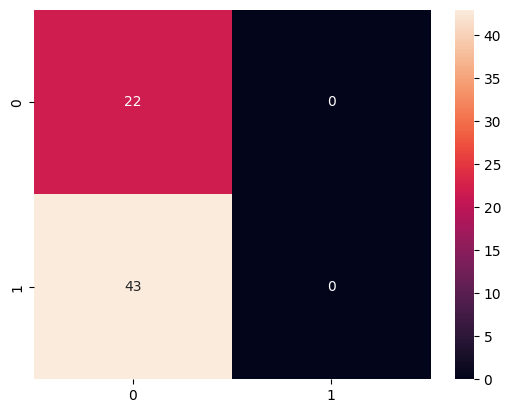

In [20]:
from keras.models import load_model
# load the model
disc_sup_trained_model = load_model(r'..\SSL_Graphs_2\disc_sup_0060.h5')

# load the dataset
testX = X_test_fin 
testy = y_test

# expand to 3d, e.g. add channels
testX = expand_dims(testX, axis=-1)

# convert from ints to floats
testX = testX.astype('float32')

# scale from [0,255] to [-1,1]
testX = (testX - 127.5) / 127.5

# evaluate the model
_, test_acc = disc_sup_trained_model.evaluate(testX, testy, verbose=0)
print('Test Accuracy: %.3f%%' % (test_acc * 100))

# Predicting the Test set results
y_pred_test = disc_sup_trained_model.predict(testX)
prediction_test = np.argmax(y_pred_test, axis=1)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(testy, prediction_test)
sns.heatmap(cm, annot=True)
